# UK Voting Intention Survey Analysis
SHGH Technical Task

Tiffany Lam

# Task 1

## Library Imports

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

## Exploratory Data Analysis

### Data Loading
The survey data is loaded and column names are renamed for readability. Serial number is set as the index for row identification.

In [2]:
# Load survey data as dataframe
election_df = pd.read_csv('Stonehaven_tech_test_survey_data.csv')
election_df

,serial_number,gender,age,actual_age,which_of_the_following_best_describes_your_current_working_status,which_one_of_these_regions_do_you_live_in,what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted,work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for,do_you_work_in,political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics,...,general_attitudes_britain_is_stronger_when_it_forms_partnerships_with_other_countries,general_attitudes_i_worry_that_cuts_in_defence_spending_mean_britain_can_no_longer_defend_itself,general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies,general_attitudes_there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today,general_attitudes_government_should_always_put_the_needs_of_british_people_ahead_of_others,general_attitudes_the_uk_should_be_more_outward_looking_in_nature,general_attitudes_i_consider_myself_working_class,general_attitudes_big_business_takes_advantage_of_ordinary_people,goal_importance_most_important,voting_intention_which_party_would_you_vote_for_if_there_was_a_general_election_tomorrow
0,13,Male,65+,77,Retired on a state pension only,East of England,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,...,Agree slightly,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Disagree strongly,Conserving the oceans,Conservative
1,14,Female,55-64,63,Retired with a private pension,West Midlands,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,...,Neither agree nor disagree,Agree slightly,Agree slightly,Agree strongly,Agree strongly,Neither agree nor disagree,Disagree slightly,Agree slightly,"Industry, innovation, and infrastructure",Conservative
2,17,Female,65+,65,Retired on a state pension only,London,Prefer not to answer,Private sector firm or company (e.g. limited c...,NaN,Not very much,...,Agree strongly,Agree slightly,Neither agree nor disagree,Neither agree nor disagree,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Conserving life on land,Liberal Democrat
3,18,Male,45-54,49,Working full time - working 30 hours per week ...,South West,"ú34,001 to ú41,000",Private sector firm or company (e.g. limited c...,NaN,Quite a lot,...,Agree strongly,Agree slightly,Disagree slightly,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Neither agree nor disagree,Stopping climate change,Labour
4,19,Female,18-24,24,"House person, housewife, househusband, etc.",West Midlands,"ú7,001 to ú14,000",Private sector firm or company (e.g. limited c...,NaN,Some,...,Disagree slightly,Agree slightly,Neither agree nor disagree,Agree slightly,Agree strongly,Agree slightly,Agree slightly,Don't know,Providing quality education,Don't know
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1862,Female,45-54,46,"House person, housewife, househusband, etc.",East of England,"ú28,001 to ú34,000",Other,NaN,Not very much,...,Don't know,Don't know,Don't know,Agree slightly,Agree strongly,Don't know,Don't know,Don't know,Good health and well-being,Would not vote
1495,1863,Male,25-34,27,Working full time - working 30 hours per week ...,West Midlands,"ú34,001 to ú41,000",Self-employed,NaN,Not very much,...,Disagree slightly,Agree slightly,Agree strongly,Agree slightly,Disagree strongly,Neither agree nor disagree,Neither agree nor disagree,Agree slightly,Ensuring nobody goes hungry,Would not vote
1496,1864,Male,35-44,38,Working full time - working 30 hours per week ...,Wales,"ú21,001 to ú28,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,...,Disagree strongly,Agree strongly,Agree strongly,Disagree strongly,Agree strongly,Disagree strongly,Agree strongly,Agree strongly,Stopping climate change,Conservative
1497,1865,Female,18-24,22,Not working and not seeking work/ Student,West M

In [3]:
# View column names
print(election_df.columns)

Index(['serial_number', 'gender', 'age', 'actual_age',
       'which_of_the_following_best_describes_your_current_working_status',
       'which_one_of_these_regions_do_you_live_in',
       'what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted',
       'work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for',
       'do_you_work_in',
       'political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics',
       'eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016',
       'which_of_the_following_statements_apply_to_you_my_parents_live_nearby',
       'which_of_the_following_statements_apply_to_you_i_grew_up_in_a_one_parent_household',
       'which_of_the_following_statements_apply_to_you_i_take_public_transport_regularly',
       'which_of_the_following_statements_apply_to_you_i_have_done_manual_labour_work_in_the_past',
       'which_of_the_following_statements_apply_to_you_i_own_more_th

In [4]:
# Define column rename mapping
column_rename = {
    'serial_number': 'serial',
    'gender': 'gender',
    'age': 'age_band',
    'actual_age': 'age',
    'which_of_the_following_best_describes_your_current_working_status': 'working_status',
    'which_one_of_these_regions_do_you_live_in': 'region',
    'what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted': 'income',
    'work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for': 'work_organisation',
    'do_you_work_in': 'work_sector',
    'political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics': 'political_interest',
    'eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016': 'eu_referendum',
    'which_of_the_following_statements_apply_to_you_my_parents_live_nearby': 'stmt_parents_nearby',
    'which_of_the_following_statements_apply_to_you_i_grew_up_in_a_one_parent_household': 'stmt_one_parent_household',
    'which_of_the_following_statements_apply_to_you_i_take_public_transport_regularly': 'stmt_public_transport',
    'which_of_the_following_statements_apply_to_you_i_have_done_manual_labour_work_in_the_past': 'stmt_manual_labour',
    'which_of_the_following_statements_apply_to_you_i_own_more_than_one_property': 'stmt_multiple_properties',
    'which_of_the_following_statements_apply_to_you_i_have_been_made_redundant_in_my_lifetime': 'stmt_made_redundant',
    'which_of_the_following_statements_apply_to_you_i_have_a_health_issue_disability_that_affects_the_jobs_i_can_take': 'stmt_health_disability',
    'which_of_the_following_statements_apply_to_you_i_care_for_a_child_with_a_serious_health_issue_disability': 'stmt_carer',
    'which_of_the_following_statements_apply_to_you_i_travel_abroad_regularly_at_least_once_every_year_or_so': 'stmt_travel_abroad',
    'which_of_the_following_statements_apply_to_you_i_predominantly_earn_my_living_using_my_hands_physical_capabilities': 'stmt_physical_work',
    'which_of_the_following_statements_apply_to_you_i_predominantly_earn_a_living_with_my_cognitive_mental_capabilities': 'stmt_cognitive_work',
    'which_of_the_following_statements_apply_to_you_i_had_a_great_education_growing_up': 'stmt_great_education',
    'which_of_the_following_statements_apply_to_you_i_know_how_to_use_microsoft_excel_spreadsheets': 'stmt_excel',
    'which_of_the_following_statements_apply_to_you_i_have_lived_in_london_at_some_point_in_my_life': 'stmt_lived_london',
    'which_of_the_following_statements_apply_to_you_i_have_worked_or_lived_abroad_in_my_life': 'stmt_lived_abroad',
    'which_of_the_following_statements_apply_to_you_none_of_these': 'stmt_none',
    'which_of_the_following_statements_apply_to_you_dont_know': 'stmt_dont_know',
    'general_attitudes_britain_is_the_greatest_country_in_the_world': 'att_britain_greatest',
    'general_attitudes_keeping_a_tight_control_over_spending_should_be_the_governments_main_economic_priority': 'att_fiscal_control',
    'general_attitudes_tackling_poverty_and_inequality_should_be_the_governments_top_priority': 'att_poverty_priority',
    'general_attitudes_britain_is_stronger_when_it_forms_partnerships_with_other_countries': 'att_international_partnerships',
    'general_attitudes_i_worry_that_cuts_in_defence_spending_mean_britain_can_no_longer_defend_itself': 'att_defence_cuts',
    'general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies': 'att_immigration_priority',
    'general_attitudes_there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today': 'att_welfare_reliance',
    'general_attitudes_government_should_always_put_the_needs_of_british_people_ahead_of_others': 'att_british_first',
    'general_attitudes_the_uk_should_be_more_outward_looking_in_nature': 'att_outward_looking',
    'general_attitudes_i_consider_myself_working_class': 'att_working_class',
    'general_attitudes_big_business_takes_advantage_of_ordinary_people': 'att_big_business',
    'goal_importance_most_important': 'goal_importance',
    'voting_intention_which_party_would_you_vote_for_if_there_was_a_general_election_tomorrow': 'vote_intention'
}

# Rename columns
election_df = election_df.rename(columns=column_rename)

In [5]:
# Set serial as index
election_df = election_df.set_index('serial')

### Pre-Processing

#### Duplicates Check
The dataset is checked for exact duplicate rows. Serial 200 appears 32 times and all rows are identical, so duplicates are dropped keeping the first occurrence.

In [6]:
# Check for exact duplicates
n_exact_dupes = election_df.duplicated(keep=False)
print(f"Exact duplicates: {n_exact_dupes.sum()}")
election_df[n_exact_dupes]

Exact duplicates: 32


,gender,age_band,age,working_status,region,income,work_organisation,work_sector,political_interest,eu_referendum,...,att_international_partnerships,att_defence_cuts,att_immigration_priority,att_welfare_reliance,att_british_first,att_outward_looking,att_working_class,att_big_business,goal_importance,vote_intention
serial,,,,,,,,,,,,,,,,,,,,,
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative
200,Female,55-64,64,Retired with a private pension,East Midlands,"ú14,001 to ú21,000",Other public sector employer (e.g. Central Gov...,"Education (schools, colleges and universities)",Quite a lot,Leave,...,Disagree slightly,Agree strongly,Agree strongly,Agree strongly,Agree strongly,Disagree slightly,Agree slightly,Neither agree nor disagree,"Peace, justice, and strong institutions",Conservative


In [7]:
# Confirm serial 200 duplicates are identical across all columns
serial_200 = election_df.loc[election_df.index == 200]
print(f"Serial 200 appears {len(serial_200)} times")
print(f"All rows identical: {serial_200.nunique().max() == 1}")

Serial 200 appears 32 times
All rows identical: True


In [8]:
# Drop duplicates, keeping first occurrence
election_df = election_df[~election_df.index.duplicated(keep='first')].copy()
election_df

,gender,age_band,age,working_status,region,income,work_organisation,work_sector,political_interest,eu_referendum,...,att_international_partnerships,att_defence_cuts,att_immigration_priority,att_welfare_reliance,att_british_first,att_outward_looking,att_working_class,att_big_business,goal_importance,vote_intention
serial,,,,,,,,,,,,,,,,,,,,,
13,Male,65+,77,Retired on a state pension only,East of England,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,Remain,...,Agree slightly,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Disagree strongly,Conserving the oceans,Conservative
14,Female,55-64,63,Retired with a private pension,West Midlands,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,Leave,...,Neither agree nor disagree,Agree slightly,Agree slightly,Agree strongly,Agree strongly,Neither agree nor disagree,Disagree slightly,Agree slightly,"Industry, innovation, and infrastructure",Conservative
17,Female,65+,65,Retired on a state pension only,London,Prefer not to answer,Private sector firm or company (e.g. limited c...,NaN,Not very much,Remain,...,Agree strongly,Agree slightly,Neither agree nor disagree,Neither agree nor disagree,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Conserving life on land,Liberal Democrat
18,Male,45-54,49,Working full time - working 30 hours per week ...,South West,"ú34,001 to ú41,000",Private sector firm or company (e.g. limited c...,NaN,Quite a lot,Remain,...,Agree strongly,Agree slightly,Disagree slightly,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Neither agree nor disagree,Stopping climate change,Labour
19,Female,18-24,24,"House person, housewife, househusband, etc.",West Midlands,"ú7,001 to ú14,000",Private sector firm or company (e.g. limited c...,NaN,Some,NaN,...,Disagree slightly,Agree slightly,Neither agree nor disagree,Agree slightly,Agree strongly,Agree slightly,Agree slightly,Don't know,Providing quality education,Don't know
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,Female,45-54,46,"House person, housewife, househusband, etc.",East of England,"ú28,001 to ú34,000",Other,NaN,Not very much,NaN,...,Don't know,Don't know,Don't know,Agree slightly,Agree strongly,Don't know,Don't know,Don't know,Good health and well-being,Would not vote
1863,Male,25-34,27,Working full time - working 30 hours per week ...,West Midlands,"ú34,001 to ú41,000",Self-employed,NaN,Not very much,NaN,...,Disagree slightly,Agree slightly,Agree strongly,Agree slightly,Disagree strongly,Neither agree nor disagree,Neither agree nor disagree,Agree slightly,Ensuring nobody goes hungry,Would not vote
1864,Male,35-44,38,Working full time - working 30 hours per week ...,Wales,"ú21,001 to ú28,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,Leave,...,Disagree strongly,Agree strongly,Agree strongly,Disagree strongly,Agree strongly,Disagree strongly,Agree strongly,Agree strongly,Stopping climate change,Conservative


#### Missing Value Check
Three columns contain missing values. The reason for missingness differs across columns, informing how each is handled. Work sector is filled with "Not applicable" as the question was only shown to public sector workers. EU referendum and property ownership are filled with "Not answered" as the reason for missingness is unknown or random.

In [9]:
# Check overall missing value counts
missing = election_df.isnull().sum()
missing_pct = (missing / len(election_df) * 100).round(1)
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

missing_summary

,missing_count,missing_pct
work_sector,1123,76.5
stmt_multiple_properties,882,60.1
eu_referendum,362,24.7


In [10]:
# Check if property missingness correlates with particular subgroup
property_missing = election_df['stmt_multiple_properties'].isnull()

print("\nAge distribution — missing vs not missing:")
print(election_df.groupby(property_missing)['age_band'].value_counts(normalize=True).unstack(0))

print("\nWorking status — missing vs not missing:")
print(election_df.groupby(property_missing)['working_status'].value_counts(normalize=True).unstack(0))

print("\nRegion — missing vs not missing:")
print(election_df.groupby(property_missing)['region'].value_counts(normalize=True).unstack(0))

print("\nWork organisation — missing vs not missing:")
print(election_df.groupby(property_missing)['work_organisation'].value_counts(normalize=True).unstack(0))


Age distribution — missing vs not missing:
stmt_multiple_properties     False     True 
age_band                                    
18-24                     0.146758  0.091837
25-34                     0.134812  0.145125
35-44                     0.189420  0.192744
45-54                     0.172355  0.199546
55-64                     0.136519  0.158730
65+                       0.220137  0.212018

Working status — missing vs not missing:
stmt_multiple_properties                               False     True 
working_status                                                        
House person, housewife, househusband, etc.         0.097270  0.082766
Not working and not seeking work/ Student           0.095563  0.068027
Not working/ temporarily unemployed/ sick but s...  0.061433  0.045351
Retired on a state pension only                     0.066553  0.040816
Retired with a private pension                      0.155290  0.183673
Working full time - working 30 hours per week o...  0.346

In [11]:
# Fill missing values in do_you_work with Not applicable, question only answered by public sector workers
election_df['work_sector'] = (election_df['work_sector'].fillna('Not applicable'))

# Fill missing values in eu_referendum with Not answered, reason for missingness unknown
election_df['eu_referendum'] = (election_df['eu_referendum'].fillna('Not answered'))

# Fill missing values in property_ownership with Not answered, missingness appears random
election_df['stmt_multiple_properties'] = (election_df['stmt_multiple_properties'].fillna('Not answered'))

#### Income Cleaning
Income brackets contain an encoding issue where £ is represented as ú. This is corrected before encoding.

In [12]:
# Fix currency encoding, replace ú with £
election_df['income'] = election_df['income'].str.replace('ú', '£', regex=False)

#### Feature Encoding
Features are encoded based on their variable type. Ordinal variables preserve their natural ordering. Binary columns are encoded as 0/1. Nominal variables are one-hot encoded. 

Income "Prefer not to answer" and attitude " Don't know responses remain as NaN after encoding, affecting 23.2% of rows. Dropping these rows would result in a significant loss from an already small dataset, so imputation is used to retain them. Income missingness shows no strong correlation with voting intention, so a binary flag is created and the median is imputed. Attitude "Don't know" responses are correlated with political disengagement, so a binary flag is created before imputing with -99 to keep these responses distinct from the ordinal scale after standardisation. 

In [13]:
# Ordinal encoding
# Income
income_map = {
    'Up to £7,000': 1,
    '£7,001 to £14,000': 2,
    '£14,001 to £21,000': 3,
    '£21,001 to £28,000': 4,
    '£28,001 to £34,000': 5,
    '£34,001 to £41,000': 6,
    '£41,001 to £48,000': 7,
    '£48,001 to £55,000': 8,
    '£55,001 to £62,000': 9,
    '£62,001 to £69,000': 10,
    '£69,001 to £76,000': 11,
    '£76,001 to £83,000': 12,
    '£83,001 or more': 13,
    'Prefer not to answer': np.nan
}
election_df['income_encoded'] = election_df['income'].map(income_map)

# Political interest
interest_map = {
    'None at all': 0,
    'Not very much': 1,
    'Some': 2,
    'Quite a lot': 3,
    'A great deal': 4
}
election_df['political_interest_encoded'] = election_df['political_interest'].map(interest_map)

# Attitude columns — Likert scale
likert_map = {
    'Disagree strongly': -2,
    'Disagree slightly': -1,
    'Neither agree nor disagree': 0,
    'Agree slightly': 1,
    'Agree strongly': 2,
    "Don't know": np.nan
}

for col in election_df.filter(like='att_').columns:
    election_df[col + '_encoded'] = election_df[col].map(likert_map)

In [14]:
# Specify attention columns
att_og_cols = election_df.filter(like='att_').columns
att_og_cols = att_og_cols[~att_og_cols.str.endswith('_encoded')]

att_encoded_cols = att_og_cols + '_encoded'

# Count rows with at least one NaN across all encoded columns
missing_cols = (
    ['income_encoded']
    + list(att_encoded_cols)
)

rows_with_nan = election_df[missing_cols].isnull().any(axis=1).sum()
print(f"Rows with at least one NaN: {rows_with_nan} ({rows_with_nan / len(election_df):.1%})")

Rows with at least one NaN: 341 (23.2%)


In [15]:
# Check null values for Income
income_missing = election_df['income_encoded'].isnull()
print(f"income_encoded: {income_missing.sum()} missing ({income_missing.sum()/len(election_df):.1%})")

# Check if missingness correlates with outcome
print(election_df.groupby(income_missing)['vote_intention'].value_counts(normalize=True).unstack(0))

income_encoded: 136 missing (9.3%)
income_encoded       False     True 
vote_intention                      
Another party     0.150150  0.139706
Conservative      0.177928  0.205882
Don't know        0.181682  0.250000
Labour            0.208709  0.110294
Liberal Democrat  0.123874  0.102941
Plaid Cymru       0.008258       NaN
Rather not say    0.003754  0.029412
SNP               0.028529  0.036765
Would not vote    0.117117  0.125000


In [16]:
# Check null values for attention columns
for col in att_encoded_cols:
    n_missing = election_df[col].isnull().sum()
    if n_missing > 0:
        print(f"\n{col}: {n_missing} missing ({n_missing/len(election_df):.1%})")
        print(election_df.groupby(election_df[col].isnull())['vote_intention'].value_counts(normalize=True).unstack(0))


att_britain_greatest_encoded: 60 missing (4.1%)
att_britain_greatest_encoded     False     True 
vote_intention                                  
Another party                 0.152699  0.066667
Conservative                  0.181818  0.150000
Don't know                    0.183239  0.300000
Labour                        0.202415  0.133333
Liberal Democrat              0.124290  0.066667
Plaid Cymru                   0.007812       NaN
Rather not say                0.005682  0.016667
SNP                           0.030540       NaN
Would not vote                0.111506  0.266667

att_fiscal_control_encoded: 98 missing (6.7%)
att_fiscal_control_encoded     False     True 
vote_intention                                
Another party               0.156204  0.051020
Conservative                0.189781  0.051020
Don't know                  0.180292  0.295918
Labour                      0.202920  0.153061
Liberal Democrat            0.124818  0.081633
Plaid Cymru                 0.008029

In [17]:
# Impute missing income values, not correlated with vote intention
# Add binary flag to capture prefer not to answer signal
election_df['income_prefer_not_to_answer'] = (
    election_df['income'] == 'Prefer not to answer'
).astype(int)
# Impute with median as missingness is random
election_df['income_encoded'] = election_df['income_encoded'].fillna(
    election_df['income_encoded'].median()
)

# Impute missing attitude values, don't know is correlated with political disengagement
# Add binary flag to preserve don't know signal
# Impute with -99 to keep don't know distinct from ordinal scale
for col in att_og_cols:
    election_df[col + '_dont_know'] = election_df[col + '_encoded'].isnull().astype(int)
    election_df[col + '_encoded'] = election_df[col + '_encoded'].fillna(-99)

# Verify no NaNs remain in missing columns
print(f"Remaining NaNs: {election_df[missing_cols].isnull().sum().sum()}")

Remaining NaNs: 0


In [18]:
# Binary encoding for statement columns, excluding stmt_multiple_properties
for col in election_df.filter(like='stmt_').columns:
    if col != 'stmt_multiple_properties':
        election_df[col + '_encoded'] = election_df[col].map({'Yes': 1, 'No': 0})

In [19]:
# One hot encoding
nominal_cols = [
    'gender',
    'working_status',
    'region',
    'work_organisation',
    'work_sector',
    'goal_importance',
    'eu_referendum',
    'stmt_multiple_properties'
]

election_df_encoded = pd.get_dummies(election_df, columns=nominal_cols, drop_first=False)

In [20]:
# Assemble final feature matrix
# Drop original unencoded columns and non-feature columns
att_og_cols = att_og_cols[~att_og_cols.str.endswith('_dont_know')]
stmt_og_cols = election_df.filter(like='stmt_').columns
stmt_og_cols = stmt_og_cols[~stmt_og_cols.str.endswith('_encoded')]
cols_to_drop = (
    ['age_band', 'income', 'political_interest', 'vote_intention'] # age_band is dropped since actual values will be used
    + list(att_og_cols)
    + list(stmt_og_cols)
)

# Define feature and outcome variables
X = election_df_encoded.drop(columns=cols_to_drop, errors='ignore')
y = election_df_encoded['vote_intention']

## Data Visuals

In [21]:
# Define colour palette for consistency across plots
party_colours = {
    'Labour': '#E4003B',
    'Conservative': '#0087DC',
    'Liberal Democrat': '#FAA61A',
    'SNP': '#FDF38E',
    'Plaid Cymru': '#005B54',
    'Another party': '#B0B0B0', # lightest grey — real party, unspecified
    "Don't know": '#888888', # mid grey — genuine uncertainty
    'Would not vote': '#505050', # dark grey — deliberate abstention
    'Rather not say': '#505050' # same dark grey — deliberate non-disclosure
}

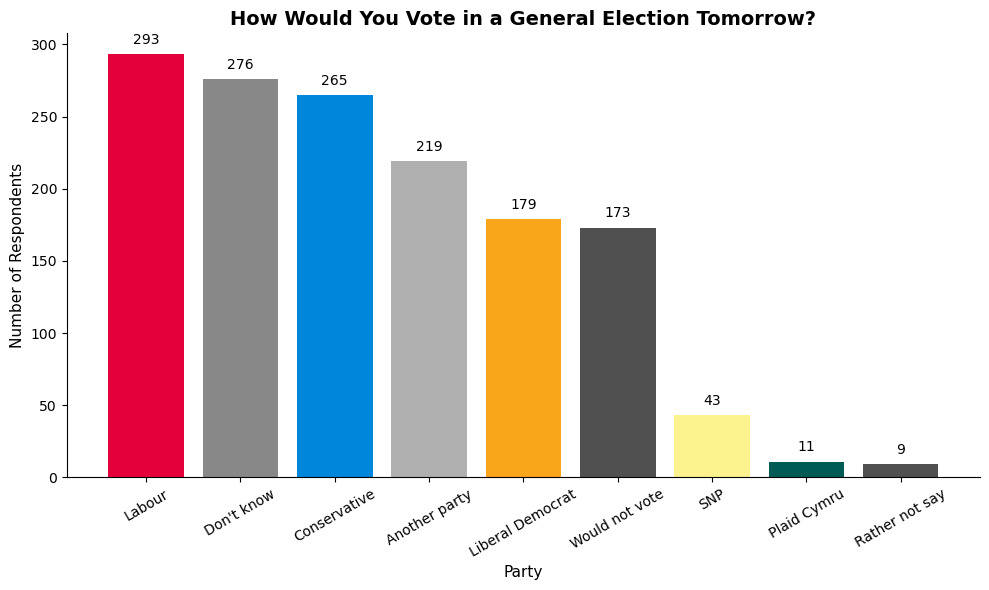

In [22]:
# Visual 1: Vote intention distribution
fig, ax = plt.subplots(figsize=(10, 6))

vote_counts = election_df['vote_intention'].value_counts()
colours = vote_counts.index.map(lambda x: party_colours.get(x, '#808080'))

bars = ax.bar(vote_counts.index, vote_counts.values, color=colours)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('How Would You Vote in a General Election Tomorrow?', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Party', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

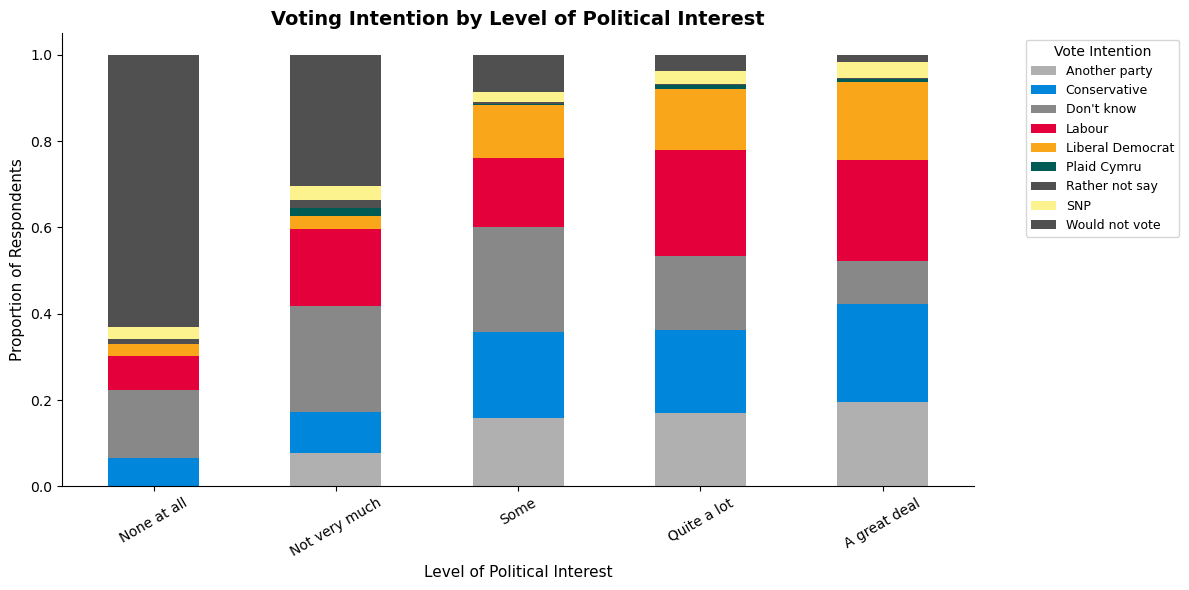

In [23]:
# Visual 2: Political interest vs Vote intention
fig, ax = plt.subplots(figsize=(12, 6))

interest_vote = (
    election_df.groupby(['political_interest', 'vote_intention'])
    .size()
    .unstack(fill_value=0)
)
interest_vote = interest_vote.div(interest_vote.sum(axis=1), axis=0)

interest_order = ['None at all', 'Not very much', 'Some', 'Quite a lot', 'A great deal']
interest_vote = interest_vote.reindex(interest_order)

bar_colours = interest_vote.columns.map(lambda x: party_colours.get(x, '#808080'))

interest_vote.plot(
    kind='bar',
    stacked=True,
    color=bar_colours,
    ax=ax
)

ax.set_title('Voting Intention by Level of Political Interest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Level of Political Interest', fontsize=11)
ax.set_ylabel('Proportion of Respondents', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Vote Intention', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

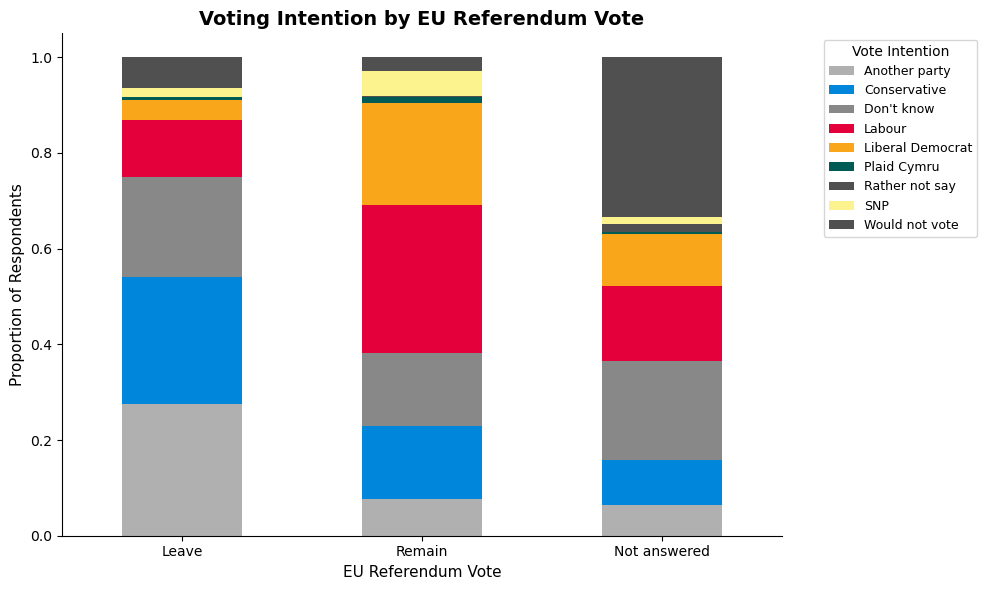

In [24]:
# Visual 3: EU referendum vs Voting intention
fig, ax = plt.subplots(figsize=(10, 6))

eu_vote = (
    election_df.groupby(['eu_referendum', 'vote_intention'])
    .size()
    .unstack(fill_value=0)
)
eu_vote = eu_vote.div(eu_vote.sum(axis=1), axis=0)

eu_order = ['Leave', 'Remain', 'Not answered']
eu_vote = eu_vote.reindex(eu_order)

bar_colours = eu_vote.columns.map(lambda x: party_colours.get(x, '#808080'))

eu_vote.plot(
    kind='bar',
    stacked=True,
    color=bar_colours,
    ax=ax
)

ax.set_title('Voting Intention by EU Referendum Vote',
             fontsize=14, fontweight='bold')
ax.set_xlabel('EU Referendum Vote', fontsize=11)
ax.set_ylabel('Proportion of Respondents', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Vote Intention', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## Modelling

### Correlation Check
Features are checked for multicollinearity before modelling. Highly correlated features can destabilise logistic regression coefficients. All highly correlated pairs result from the encoding process, including dummy variable trap, complementary binary flags, and structural relationships between related columns. These are dropped for the final modelling.

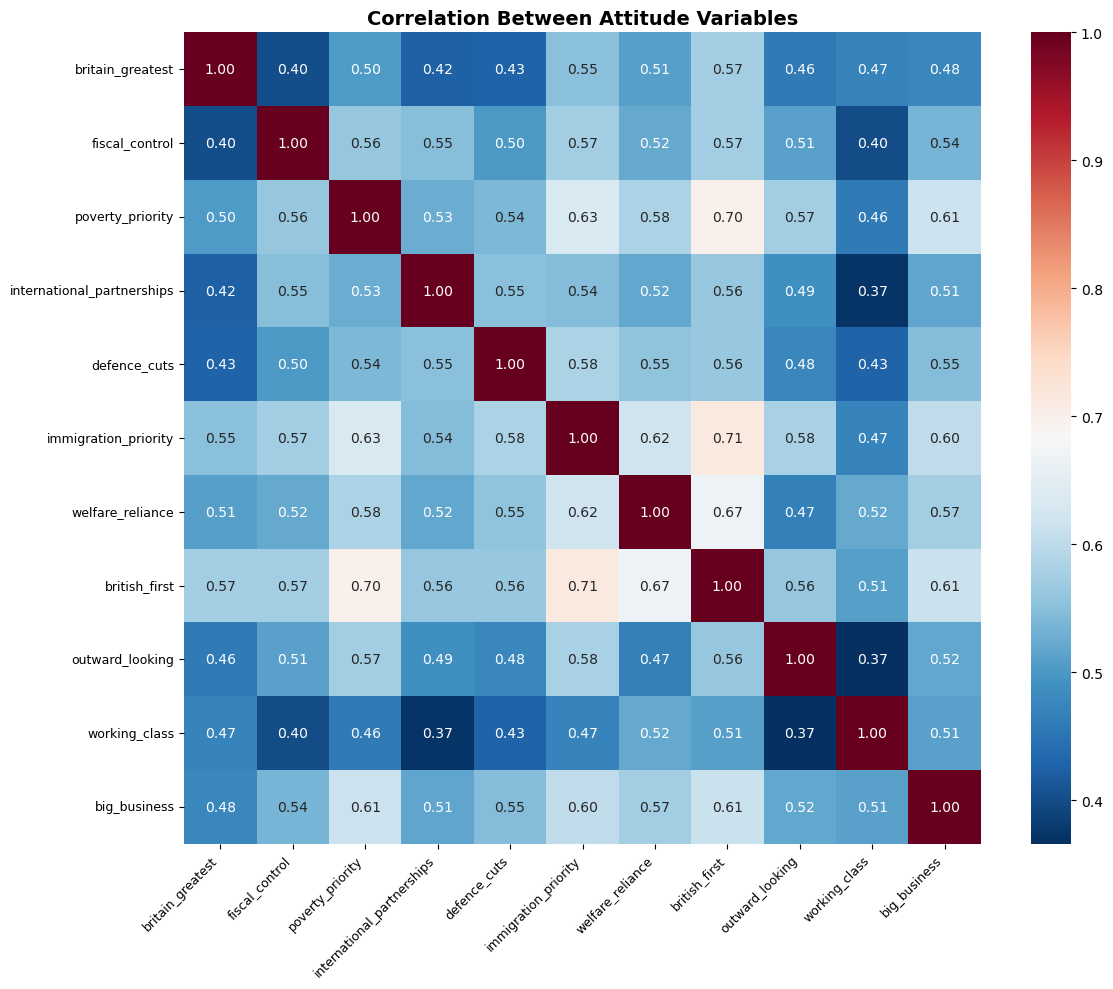


Highly correlated pairs (correlation > 0.8):


In [25]:
# Feature to feature: attitude columns heatmap
fig, ax = plt.subplots(figsize=(12, 10))

corr_att = election_df[att_encoded_cols].corr()

sns.heatmap(
    corr_att,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    ax=ax,
    xticklabels=att_encoded_cols.str.replace('att_', '').str.replace('_encoded', ''),
    yticklabels=att_encoded_cols.str.replace('att_', '').str.replace('_encoded', '')
)

ax.set_title('Correlation Between Attitude Variables',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs above threshold
threshold = 0.8
print(f"\nHighly correlated pairs (correlation > {threshold}):")
for i in range(len(corr_att.columns)):
    for j in range(i + 1, len(corr_att.columns)):
        if abs(corr_att.iloc[i, j]) > threshold:
            print(f"{corr_att.columns[i]} — {corr_att.columns[j]}: {corr_att.iloc[i, j]:.2f}")

In [26]:
# Feature-to-feature: full feature matrix high correlation pairs
corr_full = X.corr()

# Flag highly correlated pairs above threshold
print(f"Highly correlated feature pairs (correlation > {threshold}):")
for i in range(len(corr_full.columns)):
    for j in range(i + 1, len(corr_full.columns)):
        if abs(corr_full.iloc[i, j]) > threshold:
            print(f"{corr_full.columns[i]} — {corr_full.columns[j]}: {corr_full.iloc[i, j]:.2f}")

Highly correlated feature pairs (correlation > 0.8):
att_britain_greatest_encoded — att_britain_greatest_dont_know: -1.00
att_fiscal_control_encoded — att_fiscal_control_dont_know: -1.00
att_poverty_priority_encoded — att_poverty_priority_dont_know: -1.00
att_international_partnerships_encoded — att_international_partnerships_dont_know: -1.00
att_defence_cuts_encoded — att_defence_cuts_dont_know: -1.00
att_immigration_priority_encoded — att_immigration_priority_dont_know: -1.00
att_welfare_reliance_encoded — att_welfare_reliance_dont_know: -1.00
att_british_first_encoded — att_british_first_dont_know: -1.00
att_outward_looking_encoded — att_outward_looking_dont_know: -1.00
att_working_class_encoded — att_working_class_dont_know: -1.00
att_big_business_encoded — att_big_business_dont_know: -1.00
gender_Female — gender_Male: -1.00
work_organisation_Other public sector employer (e.g. Central Government) — work_sector_Not applicable: -0.86
stmt_multiple_properties_No — stmt_multiple_proper

In [27]:
# Feature-to-target
# Encode vote intention numerically for correlation calculation, approximate for multiclass target 
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Calculate correlation of each feature with encoded target
target_corr = X.corrwith(pd.Series(y_encoded, index=X.index)).abs()
target_corr = target_corr.sort_values(ascending=False)
print("Top 20 features by correlation with vote intention:")
print(target_corr.head(20))

Top 20 features by correlation with vote intention:
eu_referendum_Not answered                       0.341434
political_interest_encoded                       0.326439
eu_referendum_Leave                              0.317439
age                                              0.194429
att_poverty_priority_dont_know                   0.176030
att_poverty_priority_encoded                     0.169144
att_fiscal_control_encoded                       0.164112
att_defence_cuts_encoded                         0.162953
att_international_partnerships_dont_know         0.162333
att_fiscal_control_dont_know                     0.161513
att_international_partnerships_encoded           0.158311
att_defence_cuts_dont_know                       0.156239
region_Scotland                                  0.151553
att_british_first_encoded                        0.151481
att_immigration_priority_encoded                 0.146981
att_british_first_dont_know                      0.143559
att_immigration_prio

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [28]:
# Specify don't know columns
dont_know_cols = election_df.filter(like='att_').filter(like='_dont_know').columns

# Drop highly correlated columns
X = X.drop(columns=dont_know_cols, errors='ignore')
X = X.drop(columns=[
    'gender_Male', # Dummy variable trap
    'stmt_multiple_properties_No', # Yes/No/Not answered complementary, Yes and Not answered more informative categories
    'work_sector_Not applicable', # Work sector only filled for public sector workers, work organisation column already captures this information
    'stmt_dont_know_encoded' # No for all responses, zero-variance feature that adds no signal
])

### Train/Test split
The data is split into 80/20 into training and test sets. Stratification preserves the class distribution across both sets, which is important given the large differences in party size.

In [29]:
# Check class distribution before splitting
print("Target distribution before split:")
print(y.value_counts(normalize=True).round(3))

Target distribution before split:
vote_intention
Labour              0.200
Don't know          0.188
Conservative        0.181
Another party       0.149
Liberal Democrat    0.122
Would not vote      0.118
SNP                 0.029
Plaid Cymru         0.007
Rather not say      0.006
Name: proportion, dtype: float64


In [30]:
# Stratified split to preserve class distribution across train and test sets, given class imbalance across parties
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

### Standardization
Logistic regression requires features to be on the same scale. The scaler is fit on the training data only to prevent information from the test set influencing the model. 

In [31]:
# Initialise scaler
scaler = StandardScaler()

# Fit on training data only to prevent data leakage
# Transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Model Specifications

#### Logistic Regression
A logistic regression with L2 regularisation is trained to predict voting intention. This model was chosen for its suitability for multiclass classification and interpretability. Each feature produces a coefficient that directly indicates how strongly and in which direction it is associated with voting for a given party. L2 regularisation was applied to prevent overfitting by penalising large coefficients, producing more stable estimates across the relatively small dataset. 

In [32]:
# Fit model - logistic regression (L2 regularisation)
lr_l2 = LogisticRegression(
    penalty='l2',
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=0
)

lr_l2.fit(X_train_scaled, y_train)
y_pred_l2 = lr_l2.predict(X_test_scaled)

Logistic Regression — L2 Regularisation
                  precision    recall  f1-score   support

   Another party       0.38      0.34      0.36        44
    Conservative       0.35      0.36      0.35        53
      Don't know       0.28      0.27      0.28        55
          Labour       0.31      0.29      0.30        59
Liberal Democrat       0.24      0.22      0.23        36
     Plaid Cymru       0.00      0.00      0.00         2
  Rather not say       0.00      0.00      0.00         2
             SNP       0.35      0.75      0.48         8
  Would not vote       0.42      0.46      0.44        35

        accuracy                           0.33       294
       macro avg       0.26      0.30      0.27       294
    weighted avg       0.32      0.33      0.32       294



/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

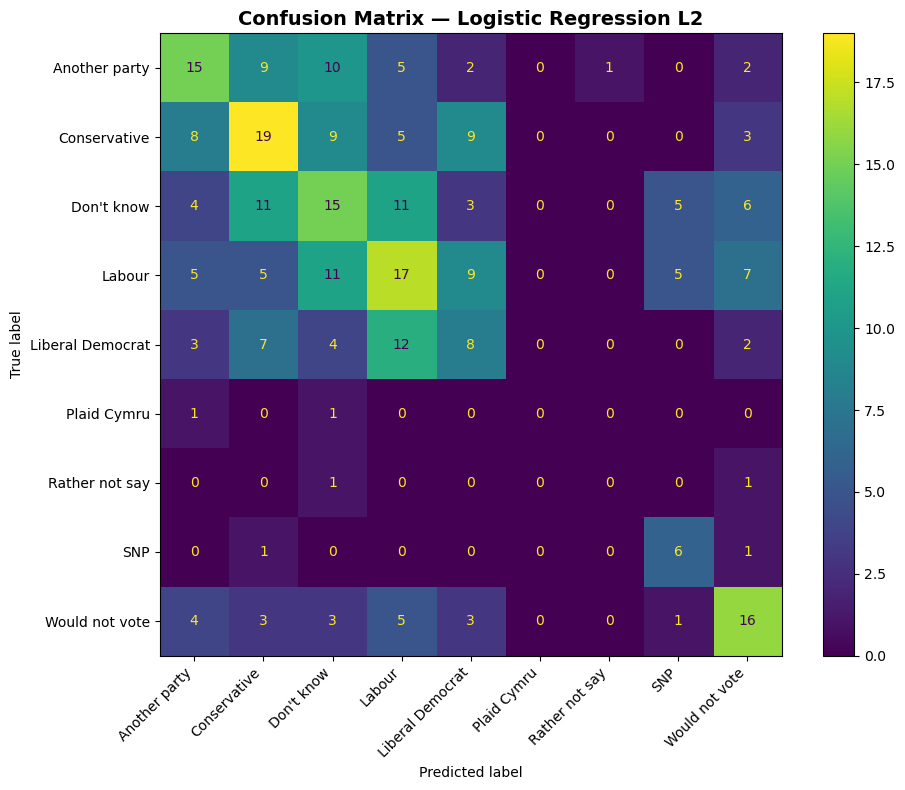

In [33]:
# Display model performance metrics
print("Logistic Regression — L2 Regularisation")
print(classification_report(y_test, y_pred_l2))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_l2,
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression L2',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The classification report shows performance metrics for each party on the held-out test set. The model achieves 33% accuracy, meaning 1 in 3 respondents are correctly predicted. Macro F1 of 27% reflects average performance across all parties equally, pulled down by poor performance on smaller parties like Plaid and Rather not say.

Performance varies significantly across parties. The model performs best on smaller, geographically concentrated parties. SNP achieves the highest F1 (0.48), with notably high recall (0.75) suggesting the model reliably identifies SNP voters, likely driven by the strong Scotland region signal. Another party and Would not vote also show relatively stronger performance.

Labour and Conservative, despite being the largest parties, show moderate performance (F1 of 0.30 and 0.35 respectively), suggesting voting intention for the major parties is harder to predict from survey characteristics alone.

Plaid Cymru and Rather not say show zero precision and recall, as the model cannot learn to predict these classes from only 2 test respondents each.

In [34]:
# Extract coefficients
coef_df = pd.DataFrame(
    lr_l2.coef_,
    index=lr_l2.classes_,
    columns=X_train_scaled.columns
)

In [35]:
# Overall most influential features across all parties
mean_abs_coef = coef_df.abs().mean(axis=0).sort_values(ascending=False)

overall_coefs = pd.DataFrame({
    'Feature': mean_abs_coef.index,
    'Mean Absolute Coefficient': mean_abs_coef.values
})

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION L2 — MEAN ABSOLUTE COEFFICIENTS ACROSS ALL PARTIES")
print("=" * 70)
print(overall_coefs.head(20).to_string(index=False))


LOGISTIC REGRESSION L2 — MEAN ABSOLUTE COEFFICIENTS ACROSS ALL PARTIES
                                   Feature  Mean Absolute Coefficient
                           region_Scotland                   0.499389
                political_interest_encoded                   0.440635
            stmt_health_disability_encoded                   0.418056
                eu_referendum_Not answered                   0.304452
                              region_Wales                   0.288876
                  att_big_business_encoded                   0.285681
               stmt_parents_nearby_encoded                   0.282209
    att_international_partnerships_encoded                   0.276692
              att_poverty_priority_encoded                   0.253158
                            income_encoded                   0.246550
goal_importance_Good health and well-being                   0.245963
             stmt_public_transport_encoded                   0.240158
                  

Looking at average feature importance across all parties, the three strongest predictors are region (Scotland), political interest, and health status, which score notably higher than all other features. The fourth strongest predictor scores around 40% lower. The dominance of Scotland reflects the concentration of SNP voters in the region. Political interest mirrors the patterns observed in EDA, where low engagement strongly predicts non-voting or undecided responses. The prominence of health status is a more unexpected finding, suggesting that respondents with a health issue or disability that affects their employment are meaningfully differentiated in their voting behaviour across parties.

In [36]:
# Coefficient analysis by party
for party in lr_l2.classes_:
    coefs = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Coefficient': coef_df.loc[party].values
    }).sort_values('Coefficient', key=abs, ascending=False)

    print("\n" + "=" * 70)
    print(f"LOGISTIC REGRESSION L2 — COEFFICIENTS | {party}")
    print("=" * 70)
    print(coefs.head(10)[['Feature', 'Coefficient']].to_string(index=False))


LOGISTIC REGRESSION L2 — COEFFICIENTS | Another party
                                                              Feature  Coefficient
                                           political_interest_encoded     0.610092
                           goal_importance_Eliminating global poverty    -0.562604
                                                  eu_referendum_Leave     0.541657
                                             att_defence_cuts_encoded     0.482486
                                             att_big_business_encoded    -0.458206
                                    stmt_one_parent_household_encoded    -0.343835
                                       stmt_health_disability_encoded    -0.334168
goal_importance_Partnerships between countries to achieve these goals    -0.329098
                                         att_poverty_priority_encoded     0.317918
                                                 eu_referendum_Remain    -0.298946

LOGISTIC REGRESSION L2 — COEFFI

Labour: Scotland is the strongest predictor but negatively, reflecting SNP competition. Prioritising poverty reduction and regular public transport use are the strongest positive predictors, consistent with Labour's urban voter base.

Conservative: Higher income is the strongest positive predictor, followed by attitudes favouring welfare reduction. Health disability is the strongest negative predictor, potentially reflecting concerns about public service provision.

Liberal Democrat: Support for international partnerships is the strongest positive predictor, followed by agreement that British interests should come first. The British First finding is counterintuitive and should be interpreted with caution given small sample sizes. Health disability is the strongest negative predictor.

SNP: Scotland dominates with a coefficient of 2.25, more than double the next strongest predictor. Health disability is positively associated with SNP voting, while prioritising good health and wellbeing is negatively associated. Given a smaller share of respondents, these patterns should be interpreted with caution.

Plaid Cymru: Wales dominates with a coefficient of 1.30. Health disability and parents living nearby are also positively associated. Given only 11 survey respondents voted Plaid Cymru, these patterns should be interpreted with caution.

Don't know: Poverty priority attitudes and female gender are the strongest positive predictors, suggesting these characteristics are associated with higher voting uncertainty. Health disability, Scotland, and strong agreement that British interests should come first all decrease likelihood of uncertainty, suggesting these groups have clearer voting intentions.

Would not vote: Low political interest is the strongest predictor, with a coefficient nearly twice the next strongest. EU referendum non-response also increases likelihood of not voting, reinforcing the disengagement pattern identified throughout the analysis.

Rather not say: Income privacy is the strongest positive predictor, consistent with a broader pattern of privacy-conscious respondents. Given only 9 survey respondents selected Rather not say, these patterns should be interpreted with caution.

#### Random Forest
A Random Forest model is trained as an additional check to assess whether non-linear relationships improve predictive performance.

In [37]:
# Fit Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    class_weight='balanced'
)

# Random Forest does not require scaling, use unscaled data
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [38]:
# Display model performance metrics
print("Random Forest")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest
                  precision    recall  f1-score   support

   Another party       0.32      0.34      0.33        44
    Conservative       0.42      0.47      0.44        53
      Don't know       0.23      0.18      0.20        55
          Labour       0.47      0.58      0.52        59
Liberal Democrat       0.43      0.28      0.34        36
     Plaid Cymru       0.00      0.00      0.00         2
  Rather not say       0.00      0.00      0.00         2
             SNP       0.45      0.62      0.53         8
  Would not vote       0.49      0.51      0.50        35

        accuracy                           0.40       294
       macro avg       0.31      0.33      0.32       294
    weighted avg       0.38      0.40      0.39       294



In [39]:
# Compare Logistic Regression L2 vs Random Forest
print("Model Comparison:")
print(f"{'Model':<30} {'Accuracy':<12} {'Macro F1':<12} {'Weighted F1'}")
print("-" * 70)
print(f"{'Logistic Regression L2':<30} "
      f"{accuracy_score(y_test, y_pred_l2):<12.3f} "
      f"{f1_score(y_test, y_pred_l2, average='macro', zero_division=0):<12.3f} "
      f"{f1_score(y_test, y_pred_l2, average='weighted', zero_division=0):.3f}")
print(f"{'Random Forest':<30} "
      f"{accuracy_score(y_test, y_pred_rf):<12.3f} "
      f"{f1_score(y_test, y_pred_rf, average='macro', zero_division=0):<12.3f} "
      f"{f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.3f}")

Model Comparison:
Model                          Accuracy     Macro F1     Weighted F1
----------------------------------------------------------------------
Logistic Regression L2         0.327        0.270        0.321
Random Forest                  0.398        0.317        0.386


Both models produce comparable accuracy, suggesting patterns identified by logistic regression are robust to the choice of modelling approach.

In [40]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 70)
print("RANDOM FOREST — TOP 20 FEATURE IMPORTANCES")
print("=" * 70)
print(feature_importance.head(20).to_string(index=False))


RANDOM FOREST — TOP 20 FEATURE IMPORTANCES
                               Feature  Importance
                       region_Scotland    0.053334
                                   age    0.049941
                          region_Wales    0.040899
            political_interest_encoded    0.037565
                        income_encoded    0.034472
          att_britain_greatest_encoded    0.032219
      att_immigration_priority_encoded    0.031227
att_international_partnerships_encoded    0.030482
              att_defence_cuts_encoded    0.030387
            att_fiscal_control_encoded    0.028069
          att_welfare_reliance_encoded    0.027870
             att_working_class_encoded    0.027830
             att_british_first_encoded    0.026875
          att_poverty_priority_encoded    0.025692
           att_outward_looking_encoded    0.025333
              att_big_business_encoded    0.023451
            eu_referendum_Not answered    0.020898
                   eu_referendum_Leave

The top features from Random Forest are broadly consistent with the logistic regression findings, with Scotland, Wales, political interest, income, and EU referendum all ranking highly in both. Two notable differences are that age ranks second in Random Forest but does not appear in the logistic regression top 20, and health disability ranks third in logistic regression but is absent from the Random Forest top 20. These differences may reflect non-linear relationships that each model captures differently. Nonetheless, the alignment across two modelling approaches supports the robustness of the key predictors identified.

# Task 2

## Library Imports

In [41]:
# Import libraries
import altair as alt
alt.renderers.enable('mimetype')
import json

## Visualisations

### Visual 1: Voting Intention Overview
Distribution of voting attention across all survey respondents.

In [42]:
# Prepare data for plotting
vote_dis = (election_df['vote_intention'].value_counts().reset_index())
vote_dis.columns = ['party', 'count']
vote_dis['pct'] = (vote_dis['count']/vote_dis['count'].sum() * 100).round(2)
vote_dis['colour'] = vote_dis['party'].map(party_colours)

In [43]:
# Build chart
vote_dis_bar = alt.Chart(vote_dis).mark_bar().encode(
    x=alt.X(
        'party:N',
        sort='-y',
        axis=alt.Axis(labelAngle=-30, title='Party', grid=False)),
    y=alt.Y(
        'count:Q',
        axis=alt.Axis(title='',grid=False),
        scale=alt.Scale(domain=[0,305])),
    color=alt.Color(
        'party:N',
        scale=alt.Scale(
            domain=list(party_colours.keys()),
            range=list(party_colours.values())),
            legend=None),
    tooltip=[
        alt.Tooltip('party:N', title='Party'),
        alt.Tooltip('count:Q', title='Respondents'),
        alt.Tooltip('pct:Q', title='Share (%)', format='.2f')]
).properties(
    title=alt.TitleParams(
        text='Labour is the most popular party, though many respondents remain undecided',
        subtitle=['Around 1 in 3 respondents are undecided or unlikely to vote','','Number of Respondents'],
        fontSize=15,
        fontWeight='bold',
        subtitleFontSize=13,
        anchor='start'),
    width=600,
    height=400
)

vote_label = vote_dis_bar.mark_text(
    align='center',
    baseline='bottom',
    dy=-2,
    fontSize=11
).encode(
    text=alt.Text('count:Q'),
    color=alt.value('black')
)

vote_dis_bar = vote_dis_bar + vote_label
vote_dis_bar

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


### Visual 2: Voting Intention Exploration
Voting intention broken down by demographic and attitudinal subgroups. Use the dropdown to explore different subgroups.

In [44]:
# Define desired subgroups
subgroup_cols = [
    'eu_referendum',
    'political_interest',
    'age_band',
    'region',
    'income'
]

# Melt subgroup into long format for dropdown selector
subgroup_dfs = []
for col in subgroup_cols:
    temp = (
        election_df.groupby([col, 'vote_intention'])
        .size()
        .reset_index(name='count')
    )
    temp = temp.rename(columns={col: 'subgroup_value'})
    temp['subgroup'] = col
    temp['total'] = temp.groupby('subgroup_value')['count'].transform('sum')
    temp['pct'] = (temp['count'] / temp['total'] * 100).round(2)
    subgroup_dfs.append(temp)

subgroup_dis = pd.concat(subgroup_dfs, ignore_index=True)

In [45]:
# Define dropdown selector
subgroup_select = alt.binding_select(
    options=subgroup_cols,
    labels=[
        'EU Referendum',
        'Political Interest',
        'Age Band',
        'Region',
        'Income'
    ],
    name='Explore by: '
)
subgroup_filter = alt.selection_point(
    fields=['subgroup'],
    bind=subgroup_select,
    value='political_interest'
)

# Build chart
subgroup_bar = alt.Chart(subgroup_dis).mark_bar().encode(
    x=alt.X(
        'pct:Q',
        axis=alt.Axis(title='% of Respondents', grid=False),
        scale=alt.Scale(domain=[0,100])),
    y=alt.Y(
        'subgroup_value:N',
        axis=alt.Axis(title='', grid=False)),
    color=alt.Color(
        'vote_intention:N',
        scale=alt.Scale(
            domain=list(party_colours.keys()),
            range=list(party_colours.values())),
        legend=alt.Legend(title='Vote Intention', values=list(party_colours.keys()))),
    tooltip=[
        alt.Tooltip('subgroup_value:N', title='Group'),
        alt.Tooltip('vote_intention:N', title='Party'),
        alt.Tooltip('count:Q', title='Respondents'),
        alt.Tooltip('pct:Q', title='Share (%)', format='.2f')
    ]
).properties(
    title=alt.TitleParams(
        text='Voting intention varies significantly across demographic and attitudinal groups',
        subtitle=['Use the dropdown to explore patterns across different subgroups',''],
        fontSize=15,
        fontWeight='bold',
        subtitleFontSize=13,
        anchor='start'
    ),
    width=600,
    height=400,
    padding={'left': 50}
).add_params(subgroup_filter).transform_filter(subgroup_filter)

subgroup_bar

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


### Visual 3: Top Voting Predictors
Top 20 features by average predictive strength across all parties, based on mean absolute coefficients from the logistic regression model.

In [46]:
# Prepare data for plotting
top_predictors = overall_coefs.head(20).copy()
top_predictors.columns = ['feature', 'mean_abs_coef']

# Clean up feature names for display
top_predictors['feature_label'] = (
    top_predictors['feature']
    .str.replace('_encoded', '')
    .str.replace('_', ' ')
    .str.replace('att ', 'Agrees: ')
    .str.replace('stmt ', 'Applies: ')
    .str.replace('eu referendum ', 'EU referendum: ')
    .str.replace('region ', 'Region: ')
    .str.replace('goal importance ', 'Goal: ')
    .str.replace('working status ', 'Working status: ')
    .str.replace('working organisation ', 'Working organisation: ')
    .str.title()
    .str.replace('Eu Referendum', 'EU Referendum')
)

In [47]:
# Build chart
predictors_bar = alt.Chart(top_predictors).mark_bar().encode(
    x=alt.X(
        'mean_abs_coef:Q',
        axis=alt.Axis(title='Mean Absolute Coefficient', grid=False)),
    y=alt.Y(
        'feature_label:N',
        sort='-x',
        axis=alt.Axis(title='', grid=False)),
    tooltip=[
        alt.Tooltip('feature_label:N', title='Feature'),
        alt.Tooltip('mean_abs_coef:Q', title='Mean Absolute Coefficient', format='.3f')]
).properties(
    title=alt.TitleParams(
        text='Scotland, political engagement, and health status are the strongest predictors of voting intention',
        subtitle=['Averaged across all parties, these three features score 0.42-0.50, well above the next predictor at 0.30',''],
        fontSize=15,
        fontWeight='bold',
        subtitleFontSize=13,
        anchor='start'
    ),
    width=600,
    height=500
)

predictors_bar

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


### Visual 4: Voting Predictors by Party
Top 10 predictors for each party, showing the direction and strength of each feature's association with voting for that party. Use the dropdown to explore different parties.

In [48]:
# Prepare data for plotting
party_preds = coef_df.reset_index().melt(
    id_vars='index',
    var_name='feature',
    value_name='coefficient'
)
party_preds.columns = ['party', 'feature', 'coefficient']
party_preds['abs_coefficient'] = party_preds['coefficient'].abs()

# Keep top 10 features per party by absolute coefficient
party_top_preds = (
    party_preds.sort_values('abs_coefficient', ascending=False)
    .groupby('party')
    .head(10)
    .reset_index(drop=True)
)

# Clean feature labels using same convention as previous chart
party_top_preds['feature_label'] = (
    party_top_preds['feature']
    .str.replace('_encoded', '')
    .str.replace('att_', 'Agrees: ')
    .str.replace('stmt_', 'Applies: ')
    .str.replace('eu_referendum_', 'EU Referendum: ')
    .str.replace('region_', 'Region: ')
    .str.replace('goal_importance_', 'Goal: ')
    .str.replace('working_status_', 'Working Status: ')
    .str.replace('working organisation ', 'Working organisation: ')
    .str.replace('income_prefer_not_to_answer', 'Prefers not to share income')
    .str.replace('_', ' ')
    .str.title()
    .str.replace('Eu Referendum', 'EU Referendum')
)

# Add direction label
party_top_preds['direction'] = party_top_preds['coefficient'].apply(
    lambda x: 'Increases likelihood' if x > 0 else 'Decreases likelihood'
)

In [49]:
# Specify party dropdown selector
party_select = alt.binding_select(
    options=sorted(party_top_preds['party'].unique().tolist()),
    name='Select party: '
)
party_filter = alt.selection_point(
    fields=['party'],
    bind=party_select,
    value='Labour'
)

In [50]:
# Build chart
coef_bar = alt.Chart(party_top_preds).mark_bar().encode(
    x=alt.X(
        'coefficient:Q',
        axis=alt.Axis(title='Coefficient', grid=False)
    ),
    y=alt.Y(
        'feature_label:N',
        sort=alt.EncodingSortField(
            field='abs_coefficient',
            order='descending'
        ),
        axis=alt.Axis(title='', grid=False)
    ),
    color=alt.Color(
        'direction:N',
        scale=alt.Scale(
            domain=['Increases likelihood', 'Decreases likelihood'],
            range=['#4CAF50', '#E57373']
        ),
        legend=alt.Legend(title='Effect')
    ),
    tooltip=[
        alt.Tooltip('feature_label:N', title='Feature'),
        alt.Tooltip('coefficient:Q', title='Coefficient', format='.3f'),
        alt.Tooltip('direction:N', title='Effect')
    ]
).properties(
    title=alt.TitleParams(
        text='Each party is driven by a distinct combination of regional, attitudinal, and demographic factors',
        subtitle=['Use the dropdown to explore the top predictors for each party', ''],
        fontSize=15,
        fontWeight='bold',
        subtitleFontSize=13,
        anchor='start'
    ),
    width=600,
    height=400,
    padding={'left':50}
).add_params(
    party_filter
).transform_filter(
    party_filter
)

coef_bar

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


## Dashboard Creation

### Visualisation Exports

In [51]:
# Specify charts to save
charts = {
    'vote_dis': vote_dis_bar,
    'vote_subgroup': subgroup_bar,
    'vote_predictors': predictors_bar,
    'vote_pred_coefs': coef_bar
}

# Save individual chart specs as json for dashboard
chart_specs = {}
for name, chart in charts.items():
    chart_specs[name] = chart.to_json()

/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/tiffanylam/opt_1/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/

### HTML Creation

In [52]:
# Build HTML dashboard
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>UK Voting Intention Survey Analysis</title>
    <script src="https://cdn.jsdelivr.net/npm/vega@5"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-lite@5"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-embed@6"></script>
    <style>
        body {{
            max-width: 900px;
            margin: 0 auto;
            padding: 40px 20px;
            color: #333;
            line-height: 1.6;
            font-family: sans-serif;
        }}
        h1 {{
            font-size: 28px;
            font-weight: 700;
            margin-bottom: 8px
        }}
        h2 {{
            font-size: 20px;
            font-weight: 600;
            margin-top: 48px;
            margin-bottom: 8px;
            border-top: 1px solid #eee;
            padding-top: 24px;
        }}
        .intro {{
            font-size: 15px;
            color: #555;
            margin-bottom: 32px;
            padding-bottom: 24px;
            border-bottom: 2px solid #eee;
        }}
        .writeup {{
            font-size: 14px;
            color: #444;
            margin-top: 16px;
            margin-bottom: 32px;
        }}
        .chart-container {{
            margin: 24px 0;
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            font-size: 14px;
            margin: 16px 0;
        }}
        th {{
            text-align: left;
            padding: 10px 12px;
            background-color: #f5f5f5;
            border-bottom: 2px solid #ddd;
            font-weight: 600;
        }}
        td {{
            padding: 10px 12px;
            border-bottom: 1px solid #eee;
        }}
        .footer {{
            margin-top: 60px;
            padding-top: 20px;
            border-top: 1px solid #eee;
            font-size: 12px;
            color: #999;
        }}
    </style>
</head>
<body>

    <h1>UK Voting Intention Survey Analysis</h1>
    <div class="intro">
        <p>SHGH Technical Task</p>
        <p>Tiffany Lam</p>
        <p>Analysis of a survey of {n_respondents} UK respondents examining voting intention and the demographic, attitudinal, and behavioural factors that predict it. A logistic regression model (L2 regularisation) was trained to predict how respondents would vote if there was a general election tomorrow.</p>
    </div>

    <!-- SECTION 1 -->
    <h2>1. How Would Respondents Vote?</h2>
    <div class="chart-container" id="vote_dis"></div>
    <div class="writeup">
        Labour leads with 20% of respondents, followed by Conservative (18%), Another Party (15%), and Liberal Democrat (12%). Notably, around 1 in 3 respondents either said they don't know how they would vote (19%) or would not vote (12%), representing a substantial pool of persuadable or disengaged voters that parties could potentially mobilise. SNP (3%), Plaid Cymru (1%), and Rather not say (1%) represent smaller shares, reflecting their regional concentration and the sensitivity of vote disclosure for some respondents.
    </div>

    <!-- SECTION 2 -->
    <h2>2. Voting Intention by Subgroup</h2>
    <div class="chart-container" id="subgroup"></div>
    <div class="writeup">
        <p>Voting intention patterns are broadly consistent across subgroups, with Labour and Conservative leading in most groups. A few patterns stand out.</p>
        <p>Political engagement shows a clear relationship with voting behaviour. 63% of respondents with no political interest said they would not vote, compared to just 2% of the most engaged. EU referendum vote is also strongly differentiated, with Remain voters favouring Labour (31%) and Liberal Democrat (21%), while Leave voters lean toward Conservative (27%) and Another party (28%). Respondents who did not answer the EU referendum question show the highest rate of would not vote (33%), reflecting that non-response across survey questions tends to reflect broader political disengagement.</p>
        <p>Conservative support increases with both age and income, peaking at 30% among those 65 and over and 33% among the highest earners. Labour shows the opposite age pattern, strongest among 25-34 year olds (31%) and declining steadily with age.</p>
        <p>Regionally, Scotland and Wales show distinct patterns. SNP takes 35% of Scottish respondents and Plaid Cymru 15% of Welsh respondents, with near zero-support elsewhere.</p>
    </div>

    <!-- SECTION 3 -->
    <h2>3. What Predicts Voting Intention?</h2>
    <div class="writeup">
        To understand what drives voting intention, a logistic regression with L2 regularisation was trained on the survey data. This model estimates the probability of each outcome, in this case which party a respondent would vote for, based on a set of input features. This was chosen because its results are easy to interpret: each feature produces a coefficient that shows how strongly and in which direction it is associated with voting for a given party. A regularisation technique (L2) was applied to improve the reliability of these estimates by producing more stable and generalisable coefficients.
    </div>
    <div class="chart-container" id="predictors"></div>
    <div class="writeup">
        Looking at average feature importance across all parties, the three strongest predictors are region (Scotland), political interest, and health status, which score notably higher than all other features. The fourth strongest predictor scores around 40% lower. The dominance of Scotland reflects the concentration of SNP voters in the region, as identified in the subgroup analysis. Political interest similarly mirrors the patterns observed earlier, where low engagement strongly predicts non-voting or undecided responses. The prominence of health status is a more unexpected finding, suggesting that respondents who have a health issue or disability that affects their employment are meaningfully differentiated in their voting behaviour across parties.
    </div>

    <!-- SECTION 4 -->
    <h2>4. Predictors by Party</h2>
    <div class="chart-container" id="coef"></div>
    <div class="writeup">
        <p>Examining the top 10 predictors for each party reveals distinct profiles.</p>
        <p><strong>Labour:</strong> Scotland is the strongest predictor but negatively, reflecting SNP competition. Prioritising poverty reduction and regular public transport use are the strongest positive predictors, consistent with Labour's urban voter base. 
        <p><strong>Conservative:</strong> Higher income is the strongest predictor, followed by attitudes favouring welfare reduction. Health disability is the strongest negative predictor, potentially reflecting concerns about public service provision.</p>
        <p><strong>Liberal Democrat:</strong> Support for international partnerships is the strongest predictor, followed by agreement that British interests should come first. The British First finding is counterintuitive and should be interpreted with caution given small sample sizes. Health disability is the strongest negative predictor.</p>
        <p><strong>SNP:</strong> Scotland dominates with a coefficient of 2.25, more than double the next strongest predictor. Health disability is positively associated with SNP voting, while prioritising good health and wellbeing is negatively associated. Given a smaller share of respondents, these patterns should be interpreted with caution.</p>
        <p><strong>Plaid Cymru:</strong> Wales dominates with a coefficient of 1.30. Health disability and parents living nearby are also positively associated. Given only 11 survey respondents voted Plaid Cymru, these patterns should be interpreted with caution.</p>
        <p><strong>Don't know:</strong> Poverty priority attitudes and female gender are the strongest positive predictors, suggesting these characteristics are associated with higher voting uncertainty. Health disability, Scotland, and strong agreement that British interests should come first all decrease likelihood of uncertainty, suggesting these groups have clearer voting intentions.</p>
        <p><strong>Would not vote:</strong> Low political interest is the strongest predictor, with a coefficient nearly twice the next strongest predictor. EU referendum non-response also increases likelihood of not voting, reinforcing the disengagement pattern identified throughout the analysis.</p>
        <p><strong>Rather not say:</strong> Income privacy is the strongest positive predictor, consistent with a broader pattern of privacy-conscious respondents. Given only 9 survey respondents selected Rather not say, these patterns should be interpreted with caution.</p>
    </div>

    <!-- SECTION 5 -->
    <h2>5. Model Performance</h2>
    <table>
        <tr>
            <th>Metric</th>
            <th>Score</th>
        </tr>
        <tr>
            <td>Accuracy</td>
            <td>{accuracy}</td>
        </tr>
        <tr>
            <td>Macro F1</td>
            <td>{macro_f1}</td>
        </tr>
        <tr>
            <td>Random Baseline (8 classes)</td>
            <td>{baseline}</td>
        </tr>
    </table>
    <div class="writeup">
        <p>Accuracy measures the proportion of respondents whose voting intention was correctly predicted. The model achieves 33%, meaning 1 in 3 respondents are correctly predicted. Macro F1 averages performance across all eight parties equally, making it a more honest measure for this dataset given the large differences in party size. The model achieves 27% macro F1, lower than accuracy as it is pulled down by poor performance on smaller parties. Both metrics are substantially above the random baseline of approximately 12.5%, expected from random guessing across eight equally likely parties.</p>
        <p>Performance varies across parties. The model predicts voting intention more reliably for smaller, geographically concentrated parties like SNP than for major parties, where survey characteristics alone are less distinguishing.</p>
        <p>As an additional check, a Random Forest model was also tested. Unlike logistic regression, Random Forest can capture more complex, non-linear relationships. Both models produced comparable accuracy, suggesting the patterns identified are robust to the choice of modelling approach.</p>
        <p>The model's moderate performance reflects the inherent difficulty of predicting voting intention from survey data alone. Voting behaviour is shaped by many factors not captured here, including media consumption, local candidate quality, and recent political events. Nevertheless, the model meaningfully outperforms random guessing and its coefficients reveal interpretable, politically coherent patterns that align with known dynamics in UK electoral behaviour.</p>
    </div>

    <script>
        vegaEmbed('#vote_dis', {vote_dis_spec}, {{actions: false}});
        vegaEmbed('#subgroup', {subgroup_spec}, {{actions: false}});
        vegaEmbed('#predictors', {predictors_spec}, {{actions: false}});
        vegaEmbed('#coef', {coef_spec}, {{actions: false}});
    </script>

</body>
</html>
"""

In [53]:
# Specify html variables
html_output = html_template.format(
    n_respondents=len(election_df),
    accuracy=f"{accuracy_score(y_test, y_pred_l2):.1%}",
    macro_f1=f"{f1_score(y_test, y_pred_l2, average='macro', zero_division=0):.1%}",
    baseline=f"{1 / len(y.unique()):.1%}",
    vote_dis_spec=chart_specs['vote_dis'],
    subgroup_spec=chart_specs['vote_subgroup'],
    predictors_spec=chart_specs['vote_predictors'],
    coef_spec=chart_specs['vote_pred_coefs']
)

# Save to file
with open('index.html', 'w') as f:
    f.write(html_output)